# 0. Environment & Imports

In [1]:
import sys
import os

# Make src/ importable from any notebook
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Core libraries
import qiskit
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Modules
from src.circuit_generator import generate_random_circuit
import src.transformations as transformations
from src.transformations import identity_transformation
from src.transformations import barrier_only
from src.transformations import commute_independent
from src.runners import run_circuit
from src.checker import check_violation, print_comparison, counts_to_probabilities, distribution_distance
from src.analyzer import ResultAnalyzer

# Analysis & plotting
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency

print("All imports successful")
print("Qiskit version:", qiskit.__version__)

All imports successful
Qiskit version: 2.3.0


In [2]:
#quick smoke test with seed
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.measure_all()

counts = run_circuit(qc, shots=4096, seed=42)
print("Bell state counts:", counts)

Bell state counts: {'11': 2087, '00': 2009}


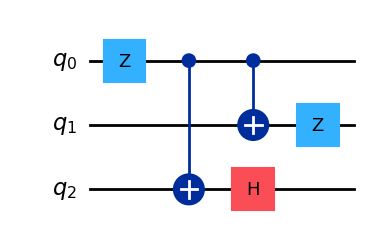

In [3]:
from src.circuit_generator import generate_random_circuit

qc = generate_random_circuit(num_qubits=3, depth=5)
qc.draw("mpl")

# Reproducibility check

In [4]:
counts_a = run_circuit(qc, shots=4096, seed=42)
counts_b = run_circuit(qc, shots=4096, seed=42)
print("Identical?", counts_a == counts_b)   # should be True

Identical? True


In [5]:
# -------------------------
# Transformation sanity check
# -------------------------

qc = generate_random_circuit(num_qubits=3, depth=5, add_measurements=True, seed=42)

qc_id = identity_transformation(qc, seed=42)
qc_barrier = barrier_only(qc, seed=42)
qc_commute = commute_independent(qc, seed=42)

print("Original vs Identity same structure?", qc != qc_id)
print("Original vs Barrier same structure?", qc != qc_barrier)

Original vs Identity same structure? True
Original vs Barrier same structure? True


In [7]:
counts_src = run_circuit(qc, shots=4096, seed=42)
counts_id = run_circuit(qc_id, shots=4096, seed=42)

print_comparison(counts_src, counts_id)


State | Source Prob | Follow-up Prob | Diff
--------------------------------------------
  000 |      0.4932 |         0.4932 | 0.0000
  001 |      0.5068 |         0.5068 | 0.0000
